In [2]:
%pip install -r /gpfs/home/bsc/bsc380741/Qubit_Alloc_Seq/requirements.txt
import json
import os
import pandas as pd
# from main import show_arch_comp_results, get_results_from_folder
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from utils.customtypes import Circuit

# plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 14})


plt.style.use('tableau-colorblind10')
palette = {
    "Vibrant Blue": "#3485fd",   # Primary brand color, deep and saturated
    "Sun Yellow": "#ffcb2f",     # Brightest, highest contrast
    "Royal Purple": "#8660cb",   # Deep, rich secondary color
    "Lush Green": "#4ab563",     # Success/Nature
    "Coral Red": "#e25563",      # Error/Warning, slightly softened
    "Ocean Turquoise": "#44d2a8",  # Clear, bright accent
    "Sunset Orange": "#fd933a",   # Warm and vibrant
    "Sky Light Blue": "#3cb1c3"   # Tertiary cool color
}

Note: you may need to restart the kernel to use updated packages.


# Embedding Size Comparison

In [ ]:
data = show_arch_comp_results('../trained/architecture')
data = sorted([(int(k.split('_')[1]),v) for k,v in data.items()])
data = data[1:] # Remove first value as it makes it difficult to see the data
x = [d[0] for d in data]
y = [d[1] for d in data]
print(data)
plt.scatter(x, y, marker="x")
plt.plot(x, y)

plt.xscale('log', base=2)
plt.xticks(x, [str(t) for t in x])

# plt.grid()
plt.xlabel("Embedding size (H), log scale")
plt.ylabel("Normalized cost")


In [ ]:
results = get_results_from_folder('../trained/architecture')
results = sorted([(int(k.split('_')[1]),v) for k,v in results.items()])[1:]

# plt.grid()

for (k,v) in results:
  cost = v['validation_cost']
  plt.plot(list(range(len(cost))), cost, label=k)

plt.legend(loc="best")
plt.xlabel("Train iteration")
plt.ylabel("Normalized cost")

# Depth comparison

In [41]:
data = show_arch_comp_results('../trained/shape')
data = {k.split('_')[1]:v for k,v in data.items()}

# Extract keys and values
labels = ['direct', 'double', 'triple', 'end']
values = list(data[l] for l in labels)

# Create bar plot
bars = plt.bar(labels, values)
plt.ylim((1.4,1.6))
plt.ylabel("Normalized cost")

# plt.xticks(x, [str(t) for t in x])

NameError: name 'show_arch_comp_results' is not defined

In [ ]:
results = get_results_from_folder('../trained/shape')
results = {k.split('_')[1]:v for k,v in results.items()}

# plt.grid()

for l in labels:
  cost = results[l]['validation_cost']
  plt.plot(list(range(len(cost))), cost, label=l)

plt.legend(loc="best")
plt.xlabel("Train iteration")
plt.ylabel("Normalized cost")

# Training DA

88.15% got at least 99% valid moves in last 2.000 iters


Text(0, 0.5, 'Loss')

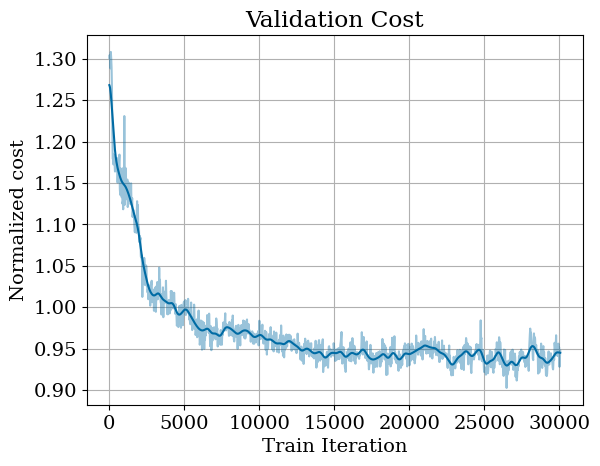

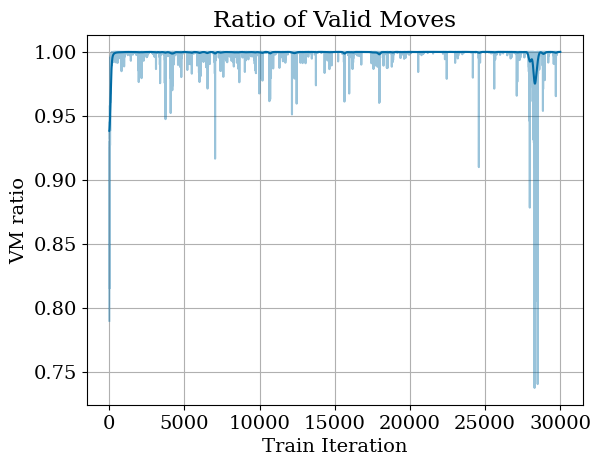

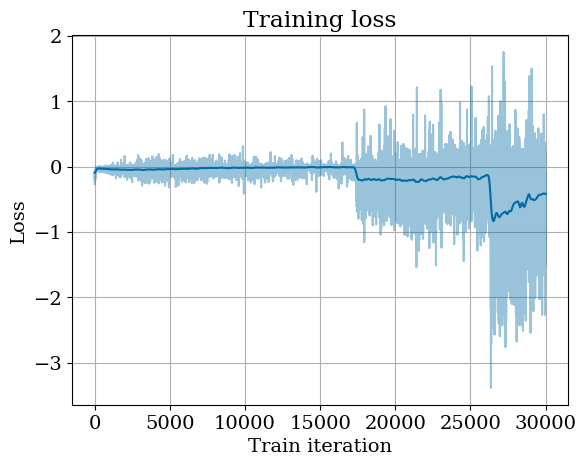

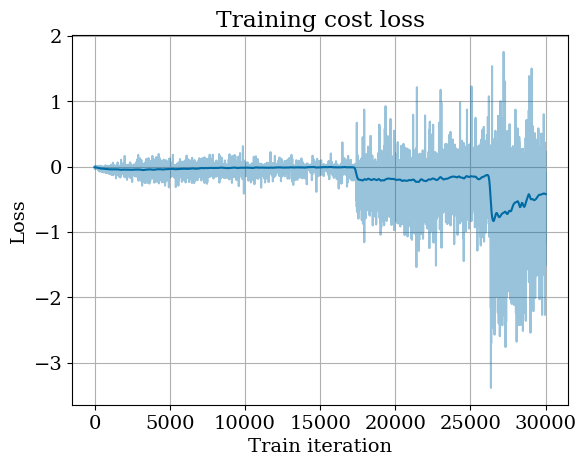

In [2]:
def load_tdata(model: str) -> dict:
    with open(f'/gpfs/scratch/bsc70/hpai/storage/projects/quantumrl/Qubit_Alloc_Seq/trained/{model}/train_data.json', 'r') as f:
        return json.load(f)

def merge_tdata(data_list: list[dict]) -> dict:
    return {k: sum(map(lambda d: d[k], data_list), [])
            for k in data_list[0].keys() if isinstance(data_list[0][k], list)}

# results = merge_tdata([load_tdata('da_seq'), load_tdata('da_seq_ft'), load_tdata('da_seq_ft_ft_v2')])
# results = merge_tdata([load_tdata('da_seq'), load_tdata('da_seq_cont')])
# results = load_tdata('da_seq')
# results = load_tdata('da_seq_new_v2')
results = load_tdata('da_seq_new_v2_cont_cont_cont')

gaussian_sigma = 7.0

plt.subplot()
plt.plot(list(i*25 for i in range(len(results['val_cost']))), results['val_cost'], alpha=0.4, c='C0')
plt.plot(list(i*25 for i in range(len(results['val_cost']))), gaussian_filter1d(results['val_cost'], sigma=gaussian_sigma), c='C0')
plt.grid()
plt.title("Validation Cost")
plt.xlabel("Train Iteration")
plt.ylabel("Normalized cost")

p99_ratio = 100*sum(int(r >= 0.99) for r in results['vm'][-2_000:])/2_000
print(f"{p99_ratio:.2f}% got at least 99% valid moves in last 2.000 iters")
plt.figure()
plt.plot(results['vm'], alpha=0.4, c='C0')
plt.plot(gaussian_filter1d(results['vm'], sigma=gaussian_sigma*10), c='C0')
plt.grid()
plt.title("Ratio of Valid Moves")
plt.xlabel("Train Iteration")
plt.ylabel("VM ratio")

plt.figure()
plt.plot(results['loss'], alpha=0.4, c='C0')
plt.plot(gaussian_filter1d(results['loss'], sigma=gaussian_sigma*10), c='C0')
plt.grid()
plt.title("Training loss")
plt.xlabel("Train iteration")
plt.ylabel("Loss")

plt.figure()
plt.plot(results['cost_loss'], alpha=0.4, c='C0')
plt.plot(gaussian_filter1d(results['cost_loss'], sigma=gaussian_sigma*10), c='C0')
plt.grid()
plt.title("Training cost loss")
plt.xlabel("Train iteration")
plt.ylabel("Loss")

In [4]:
from qalloczero.alg.directalloc import DirectAllocator
from utils.customtypes import Circuit, Hardware
from sampler.randomcircuit import RandomCircuit
import torch

hw = Hardware(core_capacities=torch.tensor([4,4,4,4]), core_connectivity=torch.ones((4,4)) - torch.eye(4))
circuit = Circuit(slice_gates=(((14, 15), (13, 3), (4, 8), (6, 1)), ((4, 10), (9, 14)), ((4, 2), (11, 1), (12, 3), (0, 5)), ((4, 9), (2, 3), (6, 0))), n_qubits=16)
# circuit = RandomCircuit(num_lq=16, num_slices=4).sample()
da: DirectAllocator = DirectAllocator.load(path='../trained/da_ft_v2', device='cuda', checkpoint=-1).set_mode(DirectAllocator.Mode.Fast)

print(f'circuit: {circuit.slice_gates}')
alloc, cost, tdata = da.optimize(circuit, hw, ret_train_data=True)
print(tdata[0].tolist())

circuit: (((14, 15), (13, 3), (4, 8), (6, 1)), ((4, 10), (9, 14)), ((4, 2), (11, 1), (12, 3), (0, 5)), ((4, 9), (2, 3), (6, 0)))


[-1.3862943649291992, -1.0986123085021973, -0.6931471824645996, 0.0, 0.0, 0.0, 0.0, 0.0, -1.38629150390625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.1871199607849121, 0.0, 0.0, 0.0, -82.45669555664062, -2.3480780124664307, 0.0]


# SOTA Comparison

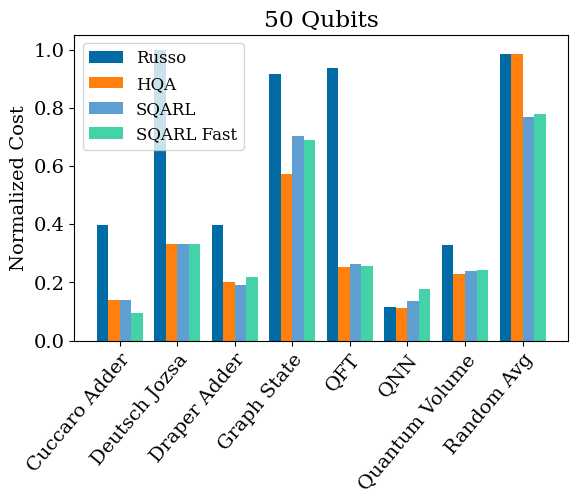

                   russo       hqa     sqarl  sqarl_fast
cuccaro_adder   0.397222  0.138889  0.138889    0.094444
deutsch_jozsa   1.000000  0.333333  0.333333    0.333333
drapper_adder   0.398501  0.200115  0.191465    0.216840
graph_state     0.917647  0.573109  0.702521    0.689076
qft             0.936275  0.252451  0.263889    0.255719
qnn             0.115828  0.110370  0.135638    0.178290
quantum_volume  0.327441  0.228719  0.237694    0.241773
random_avg      0.983514  0.983397  0.767997    0.779241


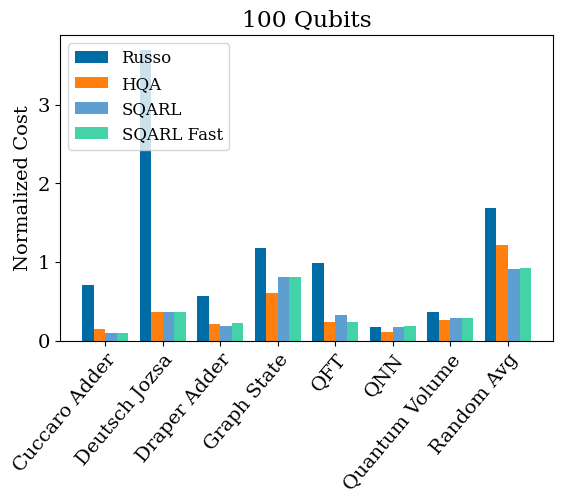

                   russo       hqa     sqarl  sqarl_fast
cuccaro_adder   0.703401  0.149660  0.100680    0.100680
deutsch_jozsa   3.704082  0.367347  0.367347    0.367347
drapper_adder   0.570840  0.207203  0.182469    0.219136
graph_state     1.181373  0.606618  0.812908    0.803105
qft             0.987472  0.232168  0.320469    0.232370
qnn             0.178369  0.106348  0.168317    0.191134
quantum_volume  0.356859  0.263680  0.286148    0.283449
random_avg      1.686818  1.213625  0.916469    0.922645


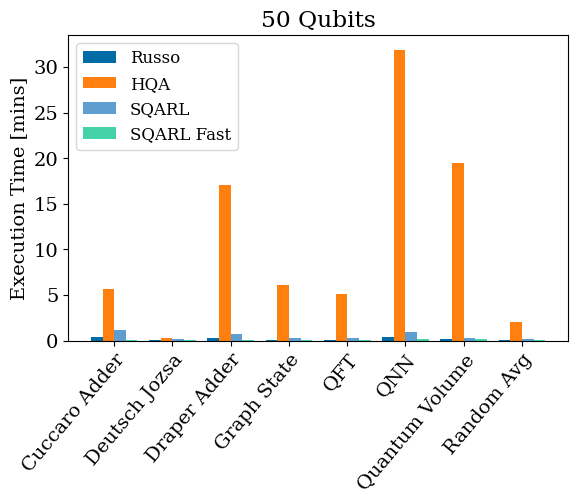

                   russo        hqa     sqarl  sqarl_fast
cuccaro_adder   0.359334   5.706623  1.111953    0.019915
deutsch_jozsa   0.052181   0.233869  0.174032    0.012908
drapper_adder   0.257165  17.041812  0.714249    0.102261
graph_state     0.091493   6.105477  0.262158    0.093898
qft             0.110793   5.109974  0.273030    0.086445
qnn             0.397469  31.933414  0.923909    0.174900
quantum_volume  0.172693  19.517362  0.308199    0.132756
random_avg      0.055570   1.996557  0.166732    0.046884


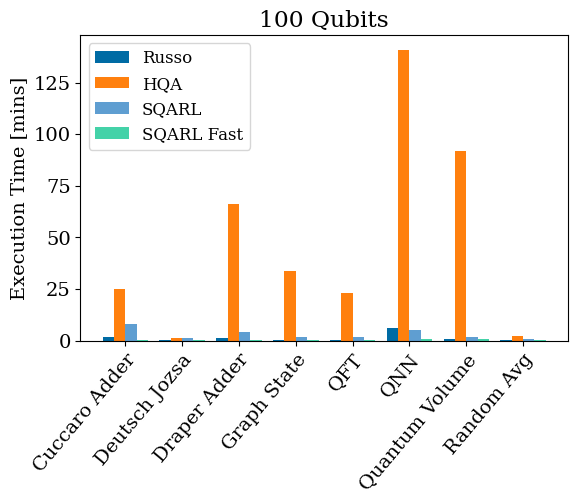

                   russo         hqa     sqarl  sqarl_fast
cuccaro_adder   1.471223   24.737959  8.148017    0.044181
deutsch_jozsa   0.216598    1.081827  1.256226    0.031141
drapper_adder   0.999608   66.332777  4.259468    0.263957
graph_state     0.379757   33.580865  1.508917    0.396371
qft             0.466565   22.999263  1.501399    0.256387
qnn             5.880145  140.993289  5.297047    0.706136
quantum_volume  0.794674   91.833026  1.567457    0.608499
random_avg      0.110201    2.196791  0.561024    0.084162


In [3]:
def format_name(name):
    if name == 'drapper_adder':
        name = 'draper_adder'
    if len(name) < 4:
        return name.upper()
    return name.replace('_', ' ').title()

def show_res(what:str, n_qubits: int, get_mine: bool):
    if get_mine:
        results = pd.read_csv(f'../data/my_{what}_{n_qubits}.csv', index_col=0)
        new_results = pd.read_csv(f'../data/my_{what}_{n_qubits}_.csv', index_col=0)
        results[['da_fast_sequential','da_fast_parallel']] = new_results[['da_fast_sequential','da_fast_parallel']]
        if what == 'cost':
            results['sqarl'] = results[['da_sequential','da_parallel']].min(axis=1)
            results['sqarl_fast'] = results[['da_fast_sequential','da_fast_parallel']].min(axis=1)
        else:
            results['sqarl'] = results[['da_sequential','da_parallel']].sum(axis=1)
            results['sqarl_fast'] = results[['da_fast_sequential','da_fast_parallel']].sum(axis=1)


    else:
        results = pd.read_csv(f'../data/sota_{what}_{n_qubits}_.csv', index_col=0)
    results.index.name = 'circuit'
    

    # Normalize results
    with open(f'../data/all_{n_qubits}.json', 'r') as f:
        data = json.load(f)
    n_qubits = data['n_qubits']

    if what == 'cost':
        for (name, slices) in data['circuits'].items():
            n_gates = Circuit(slice_gates=slices, n_qubits=n_qubits).n_gates_norm
            results.loc[name] = results.loc[name] / (n_gates)
    else:
        results /= 60


    # Avg random circuit rows
    mask = results.index.str.startswith("random")
    random_mean = results[mask].mean().to_frame().T
    random_mean.index = ["random_avg"]
    results = pd.concat([results[~mask], random_mean])


    # algorithms = results.columns
    # algorithms = ['russo', 'hqa']
    # algorithms = ['da_sequential','da_parallel']
    # algorithms = ['russo', 'hqa', 'sqarl']
    algorithms = ['russo', 'hqa', 'sqarl', 'sqarl_fast']
    # algorithms = ['russo', 'hqa', 'da_sequential','da_parallel', 'sqarl']
    experiments = [format_name(exp) for exp in results.index]

    x = list(range(len(experiments)))
    width = 0.8 / len(algorithms)

    plt.figure(figsize=(6, 5))

    alg_format = {
        'russo':            {'color':'C0', 'pattern':'/', 'name':'Russo'},
        'hqa':              {'color':'C1', 'pattern':'+', 'name':'HQA'},
        'da_sequential':    {'color':palette['Sky Light Blue'], 'pattern':'o', 'name':'Sequential'},
        'da_parallel':      {'color':palette['Royal Purple'], 'pattern':'',  'name':'Parallel'},
        'sqarl':            {'color':'C4', 'pattern':'',  'name':'SQARL'},
        'da_fast_sequential':    {'color':palette['Sky Light Blue'], 'pattern':'o', 'name':'Sequential Fast'},
        'da_fast_parallel':      {'color':palette['Royal Purple'], 'pattern':'',  'name':'Parallel Fast'},
        'sqarl_fast':            {'color':palette['Ocean Turquoise'], 'pattern':'',  'name':'SQARL Fast'},
    }

    for i, alg in enumerate(algorithms):
        x_ = [xi + i * width for xi in x]
        bars = plt.bar(
            x_,
            results[alg],
            width,
            label=alg_format[alg]['name'],
            color=alg_format[alg]['color'],
            # hatch=alg_format[alg]['pattern']
        )

    x_ = [xi + width * (len(algorithms) - 1) / 2 for xi in x]
    plt.xticks(
        x_,
        experiments,
        rotation=50,
        ha='right',
        rotation_mode='anchor'
    )

    plt.ylabel("Normalized Cost" if what == 'cost' else 'Execution Time [mins]')
    plt.legend(loc='upper left', fontsize=12)
    # plt.legend(loc='upper right', fontsize=12)
    # plt.legend(loc='upper right', bbox_to_anchor=(0.85, 1), fontsize=12)
    plt.tight_layout()
    plt.title(f'{n_qubits} Qubits')
    plt.show()

    print(results[algorithms])
    # latex_code = results[algorithms].rename(index=format_name).to_latex(
    #     index=True,           # Includes the first column (the index)
    #     column_format='l|ccccc', # 'l' for left-aligned index, 'c' for centered data
    #     # header=False,         # Set to False if you don't want the column names
    #     escape=False,         # Prevents pandas from escaping LaTeX special characters
    #     float_format="{:0.0f}".format,
    # )

    # # To get the \hline after every single row:
    # # We can replace the standard line break with a line break + \hline
    # print(latex_code.replace('\\\\\n', '\\\\\\hline\n'))

    if False:
        results = results[['russo', 'hqa', 'sqarl']]
        results = results.rename(columns={'russo':'Russo', 'hqa':'HQA', 'sqarl':'SQARL'})
        results['Imp vs Russo'] = (results['Russo'] - results['SQARL']) / results['Russo']
        results['Imp vs HQA']   = (results['HQA']   - results['SQARL']) / results['HQA']

        column_groups = [
            ('Numerical Cost', 'Russo'),
            ('Numerical Cost', 'HQA'),
            ('Numerical Cost', 'SQARL'),
            ('Improvement', 'vs Russo'),
            ('Improvement', 'vs HQA')
        ]
        results.columns = pd.MultiIndex.from_tuples(column_groups)

        # 4. Set up formatting and generate LaTeX code
        latex_table = results.style.format(
            {
                ('Numerical Cost', 'Russo'): "{:0.0f}",
                ('Numerical Cost', 'HQA'): "{:0.0f}",
                ('Numerical Cost', 'SQARL'): "{:0.0f}",
                ('Improvement', 'vs Russo'): "{:+.2%}", # Format as +/- percent
                ('Improvement', 'vs HQA'): "{:+.2%}"
            }
        ).to_latex(
            column_format='lccccc', # Table alignment: left index, five center columns
            # position_float='t',      # Use standard [t] position
            position='htbp',         # Standard float placement
            label='tab:performance_comparison',
            caption='Performance comparison with SOTA.',
            hrules=True,             # Add booktabs lines
            # multicolumn_options={'align': 'c'}, # Center the grouped headers
            sparse_index=True,       # Remove the repeating 'Circuit' name
            # multirow_align='c'       # Center multirow cells vertically
        )

        # 5. Output the final LaTeX code
        print(latex_table)


get_mine = True
for what in ['cost', 'time']:
    for n_qubits in [50, 100]:
    # for n_qubits in [100]:
        show_res(what, n_qubits, get_mine)